In [1]:
# Modules
import numpy as np
import pandas as pd
import itertools
import destruction_models as models
import tensorflow as tf
import random

from destruction_utilities import *
from destruction_statistics import *
from numpy import random
import matplotlib.pyplot as plt
from tensorflow.keras import callbacks, preprocessing
from tensorflow.keras.utils import Sequence
from tensorflow.keras.metrics import CategoricalAccuracy, Precision, AUC
from tensorflow.keras.models import load_model
from sklearn.metrics import precision_recall_curve, roc_auc_score
from os import path
import zarr
import shutil
from tensorflow.keras import backend as K
import gc
import time
import pickle

# from tensorflow.keras import layers, models, Sequential

In [2]:
CITY = 'aleppo'
TILE_SIZE = (128,128)
BATCH_SIZE = 32

In [3]:
def recall_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall

def precision_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision

def f1_m(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    return 2*((precision*recall)/(precision+recall+K.epsilon()))

auc = AUC(
    num_thresholds=200,
    curve='ROC',
)
    
def run_model(training_images, training_labels, validation_images, validation_labels, epochs=50):
    training_generator = ZarrGenerator(training_images, training_labels, batch_size=BATCH_SIZE)
    validation_generator = ZarrGenerator(validation_images, validation_labels, batch_size=BATCH_SIZE)
    
    training_callbacks = [
        callbacks.EarlyStopping(monitor='val_auc', restore_best_weights=True, patience=5),
    ]
    
    filters = random.choice([8, 16, 24, 32])
    dropout = random.choice(np.linspace(0.05, 0.5))
    epochs = random.choice(10)
    units = random.choice([16, 32, 48])
    lr = random.choice([0.001, 0.003, 0.01, 0.03, 0.1, 0.3])
    
    parameters = f'Model parameters: filters={filters}, dropout={dropout}, epochs={epochs}, units={units}, learning_rate={lr}'
    print(parameters)
    
    args  = dict(shape=(*TILE_SIZE, 3), filters=filters, units=units, dropout=dropout) # ! Check parameters before run
    model = models.convolutional_network(**args)
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy', f1_m, precision_m, recall_m, auc])

    model.summary()
    
    # Train model on dataset
    history = model.fit_generator(
        training_generator,
        validation_data=validation_generator, 
        epochs=epochs, 
        callbacks = training_callbacks
    )
    
    return model, history, parameters


# def calculate_auc(model, test_images, test_labels):
#     gc.collect(generation=2)    
#     batch_size = 5000
#     iters = test_images.shape[0] // batch_size
#     preds = []
#     labels = []
#     for i in range(0, iters):
#         end = (i+1)*batch_size
#         if i == iters - 1:
#             preds.append(model.predict(test_images[i*batch_size:]))
#             labels.append(test_labels[i*batch_size:])
#         else:
#             preds.append(model.predict(test_images[i*batch_size: end]))
#             labels.append(test_labels[i*batch_size: end])
            
#     yhat = np.squeeze(np.concatenate(preds, axis=0))
#     y = np.squeeze(np.concatenate(labels, axis=0 ))
#     roc_auc = roc_auc_score(y, yhat)
    
#     return roc_auc
    

Metal device set to: Apple M1


2022-07-09 03:08:51.215684: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2022-07-09 03:08:51.215788: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [4]:
class ZarrGenerator(Sequence):
    def __init__(self, images, labels, batch_size=BATCH_SIZE):
        self.images = images
        self.labels = labels
        self.batch_size = batch_size
        
    def __len__(self):
        return len(self.images)//self.batch_size
    
    def __getitem__(self, index):

        X = self.images[index*self.batch_size:(index+1)*self.batch_size]
        y = self.labels[index*self.batch_size:(index+1)*self.batch_size]
        
        return self.augment(X), y.flatten()
    
    def augment(self, X):
#         # Horizontal and vertical flip
#         flipping_funcs = [
#             lambda image: image,
#             lambda image: np.fliplr(image),
#             lambda image: np.flipud(image),
#             lambda image: np.flipud(np.fliplr(image))
#         ]
#         func = random.choice(flipping_funcs)
#         X = func(X)
        
        # Brightness
        alpha = random.choice(np.linspace(0.85, 1.4))
        X = X * alpha
        
        return X

In [6]:
training_images = read_zarr(CITY, 'images_conv_train_balanced')
training_labels = read_zarr(CITY, 'labels_conv_train_balanced')
validation_images = read_zarr(CITY, 'images_conv_valid_balanced')
validation_labels = read_zarr(CITY, 'labels_conv_valid_balanced')
test_images = read_zarr(CITY, 'images_conv_test_balanced')
test_labels = read_zarr(CITY, 'labels_conv_test_balanced')

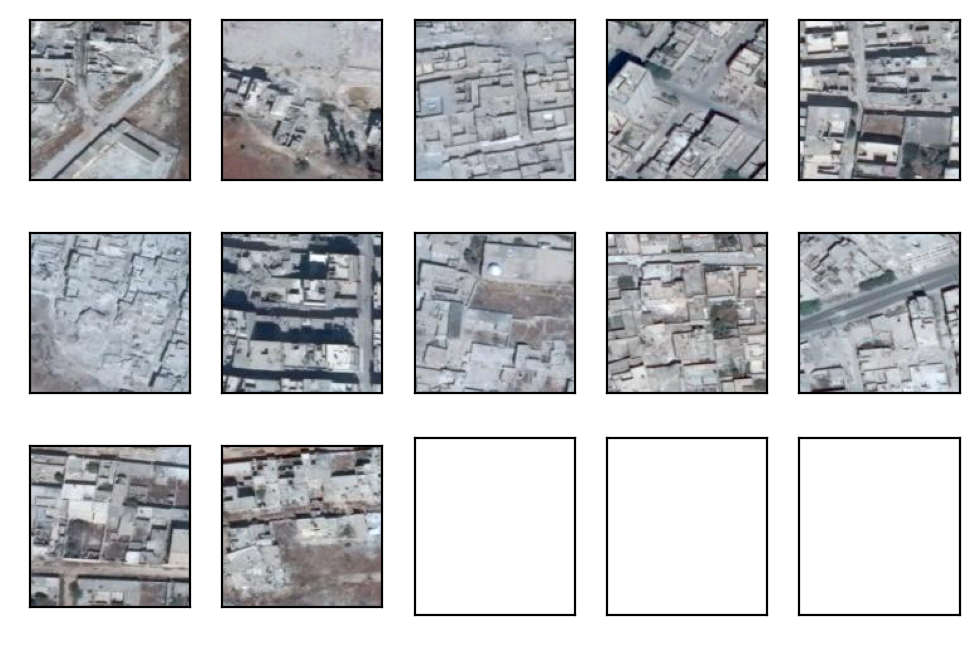

In [7]:
import matplotlib.pyplot as plt
labels = np.squeeze([training_labels[0:30]])
ones = np.where(labels==1)
images = training_images[0:100]

total_images = len(list(ones[0]))
fig, ax = plt.subplots(3, (total_images//3)+1, dpi=200, figsize =(6,4))
ax = ax.flatten()


for i, one in enumerate(list(ones[0])):
    ax[i].imshow(images[one].astype(np.uint8))

for a in ax:
    a.set_xticks([])
    a.set_yticks([])



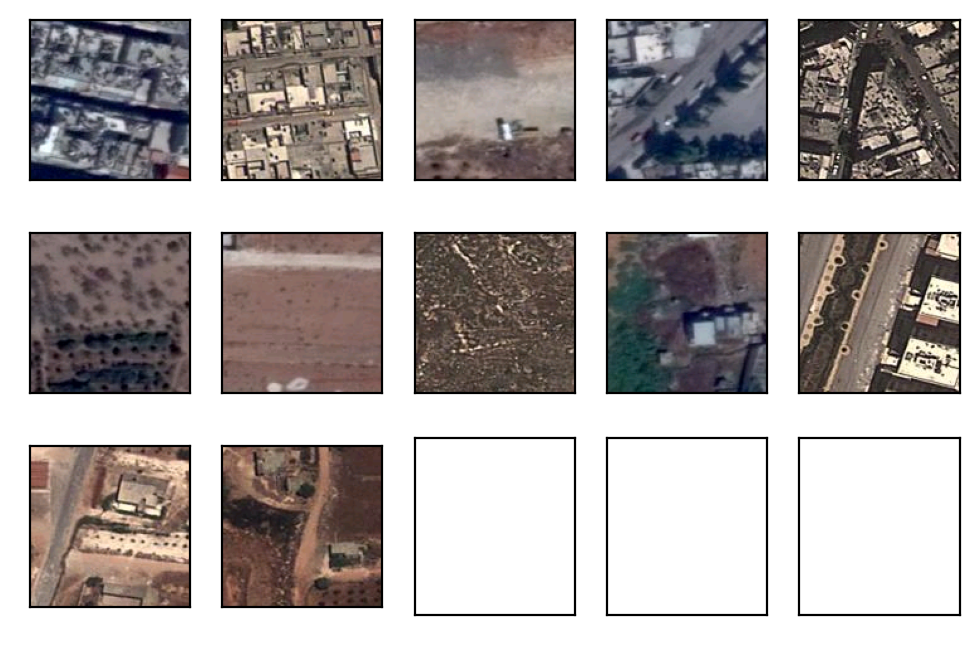

In [8]:
import matplotlib.pyplot as plt
labels = np.squeeze([training_labels[0:17]])
zeros = np.where(labels==0)
images = training_images[0:20]

total_images = len(list(zeros[0]))
fig, ax = plt.subplots(3, (total_images//3)+1, dpi=200, figsize =(6,4))
ax = ax.flatten()


for i, one in enumerate(list(zeros[0])):
    ax[i].imshow(images[one].astype(np.uint8))

for a in ax:
    a.set_xticks([])
    a.set_yticks([])



In [ ]:
for i in range(0,50):
    model = run_model(training_images, training_labels, validation_images, validation_labels, epochs=10)
    model = model[0]
    history = model[1]
    parameters = model[2]
    print("Model optimization complete..")
    
    ts = str(time.time())
    
    with open(f'../models/{CITY}_CNN_RUN{i}_hist_{ts}', 'wb') as file_pi:
        pickle.dump(history.history, file_pi)
    
    model.save(f'../models/{CITY}_CNN_RUN{i}_{ts}', save_format="h5")
    
    with open("f'../models/run_parameters.txt", "a") as file:
        file.write(f'{CITY}_CNN_RUN{i}_{ts}: \n \t{parameters}\n')